# TesTEA - Analisis Exploratorio de Datos (EDA)

Proyecto de cribado temprano de TEA (Trastorno del Espectro Autista) basado en Machine Learning.

El objetivo de este notebook es explorar y entender los datasets que vamos a utilizar
para entrenar nuestros modelos de clasificacion. Necesitamos conocer bien los datos
antes de tomar cualquier decision sobre preprocesamiento o modelado.

Trabajamos con **cuatro datasets**, todos basados en el cuestionario estandarizado
AQ-10 (Autism Quotient de 10 items) o su version Q-CHAT-10 para toddlers:

- **autism_adults**: adultos (UCI, CSV, 704 registros)
- **autism_adolescents**: adolescentes (UCI, formato ARFF, 104 registros)
- **autism_combined**: coleccion agrupada de adultos, adolescentes y ninos (Kaggle, CSV)
- **autism_toddlers**: ninos pequenos / toddlers (Kaggle, CSV)

El dataset de adolescentes viene en formato ARFF, un formato distinto al CSV que
requiere una libreria especial (scipy.io.arff) y un paso extra de limpieza, ya que
las columnas de texto se cargan como bytes en lugar de strings.


## 0. Imports y configuracion

In [6]:
# Importamos las librerias necesarias para el analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

# Configuracion visual para que los graficos se vean bien
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12


## 1. Carga de datos

Cargamos los cuatro datasets. Los tres primeros son CSV normales, pero el de
adolescentes viene en formato ARFF, asi que necesitamos usar `scipy.io.arff` y
luego convertirlo a un DataFrame de pandas.

Las rutas apuntan a la carpeta data/raw/ del proyecto. Si trabajamos en Google
Colab, hay que montar Google Drive primero y ajustar las rutas segun donde
tengamos clonado el repositorio.


In [7]:
# Cargamos los tres datasets en formato CSV
autism_adults = pd.read_csv("../data/raw/autism_screening.csv")
autism_combined = pd.read_csv("../data/raw/Autism_Screening_Data_Combined.csv")
autism_toddlers = pd.read_csv("../data/raw/Toddler Autism dataset July 2018.csv")

# El dataset de adolescentes viene en formato ARFF, no CSV.
# scipy.io.arff.loadarff devuelve una tupla (datos, metadata); solo necesitamos los datos.
raw_adolescents, _ = arff.loadarff("../data/raw/Autism-Adolescent-Data.arff")
autism_adolescents = pd.DataFrame(raw_adolescents)

print("Datasets cargados correctamente")
print(f"  - autism_adults:      {autism_adults.shape[0]} registros, {autism_adults.shape[1]} columnas")
print(f"  - autism_adolescents: {autism_adolescents.shape[0]} registros, {autism_adolescents.shape[1]} columnas")
print(f"  - autism_combined:    {autism_combined.shape[0]} registros, {autism_combined.shape[1]} columnas")
print(f"  - autism_toddlers:    {autism_toddlers.shape[0]} registros, {autism_toddlers.shape[1]} columnas")
total = autism_adults.shape[0] + autism_adolescents.shape[0] + autism_combined.shape[0] + autism_toddlers.shape[0]
print(f"  - Total de registros entre los cuatro: {total}")


Datasets cargados correctamente
  - autism_adults:      704 registros, 21 columnas
  - autism_adolescents: 104 registros, 21 columnas
  - autism_combined:    6075 registros, 15 columnas
  - autism_toddlers:    1054 registros, 19 columnas
  - Total de registros entre los cuatro: 7937


### 1.1 Decodificacion del dataset de adolescentes (formato ARFF)

Cuando cargamos un archivo ARFF con scipy, las columnas de texto no se leen
como strings normales de Python, sino como bytes (por ejemplo `b'YES'` en vez
de `'YES'`). Si no las decodificamos, cualquier comparacion o filtro con texto
va a fallar silenciosamente. Vamos a comprobarlo y corregirlo.


In [8]:
# Comprobamos el problema: las columnas de texto vienen como bytes
print("Antes de decodificar:")
print(autism_adolescents[["gender", "Class/ASD"]].head(3))
print()
print("Tipo de dato de un valor individual:", type(autism_adolescents["Class/ASD"].iloc[0]))


Antes de decodificar:
  gender Class/ASD
0   b'm'     b'NO'
1   b'm'     b'NO'
2   b'f'     b'NO'

Tipo de dato de un valor individual: <class 'bytes'>


In [9]:
# Decodificamos todas las columnas de tipo object (bytes) a string UTF-8
for col in autism_adolescents.select_dtypes([object]).columns:
    autism_adolescents[col] = autism_adolescents[col].str.decode("utf-8")

print("Despues de decodificar:")
print(autism_adolescents[["gender", "Class/ASD"]].head(3))
print()
print("Tipo de dato de un valor individual:", type(autism_adolescents["Class/ASD"].iloc[0]))


Despues de decodificar:
  gender Class/ASD
0      m        NO
1      m        NO
2      f        NO

Tipo de dato de un valor individual: <class 'str'>


In [10]:
# Las puntuaciones A1_Score a A10_Score tambien llegaron como texto ("0", "1")
# en lugar de numeros. Las convertimos a entero para poder operar con ellas
# (sumas, medias, correlaciones) igual que en el resto de datasets.
score_cols_adolescents = [f"A{i}_Score" for i in range(1, 11)]
autism_adolescents[score_cols_adolescents] = autism_adolescents[score_cols_adolescents].astype(int)

print("Tipos de las columnas de puntuacion tras la conversion:")
print(autism_adolescents[score_cols_adolescents].dtypes)


Tipos de las columnas de puntuacion tras la conversion:
A1_Score     int64
A2_Score     int64
A3_Score     int64
A4_Score     int64
A5_Score     int64
A6_Score     int64
A7_Score     int64
A8_Score     int64
A9_Score     int64
A10_Score    int64
dtype: object


## 2. Estructura de cada dataset

Antes de hacer nada, necesitamos entender que columnas tiene cada dataset,
que tipos de datos contiene cada una, y si comparten una estructura comun
(ya que los cuatro estan basados en el cuestionario AQ-10).


### 2.1 Dataset de adultos (autism_adults)

In [11]:
print("Primeras 5 filas del dataset de adultos:")
print(autism_adults.head())
print()
print("Columnas:", list(autism_adults.columns))


Primeras 5 filas del dataset de adultos:
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         1         1         1         0         0         1   
1         1         1         0         1         0         0         0   
2         1         1         0         1         1         0         1   
3         1         1         0         1         0         0         1   
4         1         0         0         0         0         0         0   

   A8_Score  A9_Score  A10_Score  ...  gender       ethnicity jundice austim  \
0         1         0          0  ...       f  White-European      no     no   
1         1         0          1  ...       m          Latino      no    yes   
2         1         1          1  ...       m          Latino     yes    yes   
3         1         0          1  ...       f  White-European      no    yes   
4         1         0          0  ...       f               ?      no     no   

   contry_of_res used_app_b

### 2.2 Dataset de adolescentes (autism_adolescents)

In [12]:
print("Primeras 5 filas del dataset de adolescentes:")
print(autism_adolescents.head())
print()
print("Columnas:", list(autism_adolescents.columns))


Primeras 5 filas del dataset de adolescentes:
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         0         0         0         1         1         1         1   
1         0         0         0         0         0         0         0   
2         0         0         0         0         0         0         0   
3         0         1         1         1         1         1         0   
4         1         1         1         1         1         1         1   

   A8_Score  A9_Score  A10_Score  ...  gender       ethnicity jundice austim  \
0         1         1          0  ...       m        Hispanic     yes    yes   
1         0         1          1  ...       m           Black      no     no   
2         0         1          1  ...       f               ?      no     no   
3         1         1          0  ...       f  White-European      no     no   
4         0         0          0  ...       f               ?      no     no   

    contry_of_res used

### 2.3 Dataset combinado (autism_combined)

In [13]:
print("Primeras 5 filas del dataset combinado:")
print(autism_combined.head())
print()
print("Columnas:", list(autism_combined.columns))


Primeras 5 filas del dataset combinado:
   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD Class
0   1   1   0   1   0   0   1   1   0    0   15   m        no         no    NO
1   0   1   1   1   0   1   1   0   1    0   15   m        no         no    NO
2   1   1   1   0   1   1   1   1   1    1   15   f        no        yes   YES
3   1   1   1   1   1   1   1   1   0    0   16   f        no         no   YES
4   1   1   1   1   1   1   1   1   1    1   15   f        no         no   YES

Columnas: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class']


### 2.4 Dataset de toddlers (autism_toddlers)

In [14]:
print("Primeras 5 filas del dataset de toddlers:")
print(autism_toddlers.head())
print()
print("Columnas:", list(autism_toddlers.columns))


Primeras 5 filas del dataset de toddlers:
   Case_No  A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat-10-Score  \
0        1   0   0   0   0   0   0   1   1   0    1        28               3   
1        2   1   1   0   0   0   1   1   0   0    0        36               4   
2        3   1   0   0   0   0   0   1   1   0    1        36               4   
3        4   1   1   1   1   1   1   1   1   1    1        24              10   
4        5   1   1   0   1   1   1   1   1   1    1        20               9   

  Sex       Ethnicity Jaundice Family_mem_with_ASD Who completed the test  \
0   f  middle eastern      yes                  no          family member   
1   m  White European      yes                  no          family member   
2   m  middle eastern      yes                  no          family member   
3   m        Hispanic       no                  no          family member   
4   f  White European       no                 yes          family member   

  Class/

### 2.5 Comparacion de estructuras entre datasets

Los cuatro datasets comparten la base del cuestionario AQ-10 (columnas A1 a A10),
pero tienen diferencias importantes en las columnas adicionales:

| Columna | adults | adolescents | combined | toddlers |
|---|---|---|---|---|
| Respuestas AQ-10 | A1_Score..A10_Score | A1_Score..A10_Score | A1..A10 | A1..A10 |
| Edad | age (anos) | age (anos) | Age (anos) | Age_Mons (meses) |
| Sexo | gender | gender | Sex | Sex |
| Etnia | ethnicity | ethnicity | -- | Ethnicity |
| Ictericia neonatal | jundice | jundice | Jauundice | Jaundice |
| Antecedentes familiares | austim | austim | Family_ASD | Family_mem_with_ASD |
| Pais | contry_of_res | contry_of_res | -- | -- |
| Quien completa el test | relation | relation | -- | Who completed the test |
| Puntuacion total | result | result | -- | Qchat-10-Score |
| Uso previo de app | used_app_before | used_app_before | -- | -- |
| Target | Class/ASD | Class/ASD | Class | Class/ASD Traits |

El dataset de adolescentes comparte exactamente la misma estructura de columnas
que el de adultos (ambos vienen de la misma fuente UCI con el mismo formato de
cuestionario), lo cual va a simplificar el preprocesamiento.


## 3. Valores faltantes

Comprobamos si hay valores nulos en cada dataset. Los valores faltantes pueden
afectar al rendimiento de los modelos y hay que decidir como tratarlos
(eliminar filas, imputar valores, etc.).


In [15]:
datasets_dict = {
    "autism_adults": autism_adults,
    "autism_adolescents": autism_adolescents,
    "autism_combined": autism_combined,
    "autism_toddlers": autism_toddlers
}

for nombre, data in datasets_dict.items():
    print("=" * 60)
    print(f"VALORES FALTANTES - {nombre}")
    print("=" * 60)
    nulos = data.isnull().sum()
    nulos_con_valores = nulos[nulos > 0]
    if len(nulos_con_valores) > 0:
        print(nulos_con_valores)
        print(f"\nTotal de filas con al menos un nulo: {data.isnull().any(axis=1).sum()}")
    else:
        print("No hay valores faltantes")
    print()


VALORES FALTANTES - autism_adults
age    2
dtype: int64

Total de filas con al menos un nulo: 2

VALORES FALTANTES - autism_adolescents
No hay valores faltantes

VALORES FALTANTES - autism_combined
No hay valores faltantes

VALORES FALTANTES - autism_toddlers
No hay valores faltantes



### Observaciones sobre valores faltantes

- **autism_adults**: 2 valores faltantes en 'age'. Son solo 2 de 704 registros
  (0.28%), asi que podemos imputarlos con la mediana o eliminar esas filas.
- **autism_adolescents**, **autism_combined** y **autism_toddlers**: no tienen
  valores faltantes (NaN reales).

Sin embargo, tanto en autism_adults como en autism_adolescents, algunas columnas
categoricas usan el valor '?' como dato desconocido, que pandas no detecta como
nulo pero que en la practica lo es. Vamos a comprobarlo en ambos datasets.


In [16]:
# Comprobamos valores '?' en las columnas categoricas de adultos y adolescentes
# porque los datasets de UCI a veces usan '?' en lugar de NaN
for nombre in ["autism_adults", "autism_adolescents"]:
    data = datasets_dict[nombre]
    print(f"Valores '?' en columnas categoricas de {nombre}:")
    cols_categoricas = data.select_dtypes(include=["object"]).columns
    encontrados = False
    for col in cols_categoricas:
        count_interrogacion = (data[col] == "?").sum()
        if count_interrogacion > 0:
            print(f"  {col}: {count_interrogacion} valores '?'")
            encontrados = True
    if not encontrados:
        print("  Ninguno")
    print()


Valores '?' en columnas categoricas de autism_adults:
  ethnicity: 95 valores '?'
  relation: 95 valores '?'

Valores '?' en columnas categoricas de autism_adolescents:
  ethnicity: 6 valores '?'
  relation: 6 valores '?'



C:\Users\adria\AppData\Local\Temp\ipykernel_2840\1598922113.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = data.select_dtypes(include=["object"]).columns
C:\Users\adria\AppData\Local\Temp\ipykernel_2840\1598922113.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/us

## 4. Distribucion de la variable objetivo (target)

La variable objetivo es la etiqueta de cribado: si el resultado del test indica
rasgos compatibles con TEA (YES/Yes) o no (NO/No).

Esto es fundamental porque si las clases estan muy desbalanceadas, tendremos
que tener cuidado con las metricas que usemos para evaluar los modelos.
En un contexto de cribado medico, un falso negativo (no detectar a alguien que
si tiene rasgos de TEA) es mucho mas grave que un falso positivo (derivar a
alguien que al final no lo necesita). Por eso priorizaremos el recall.


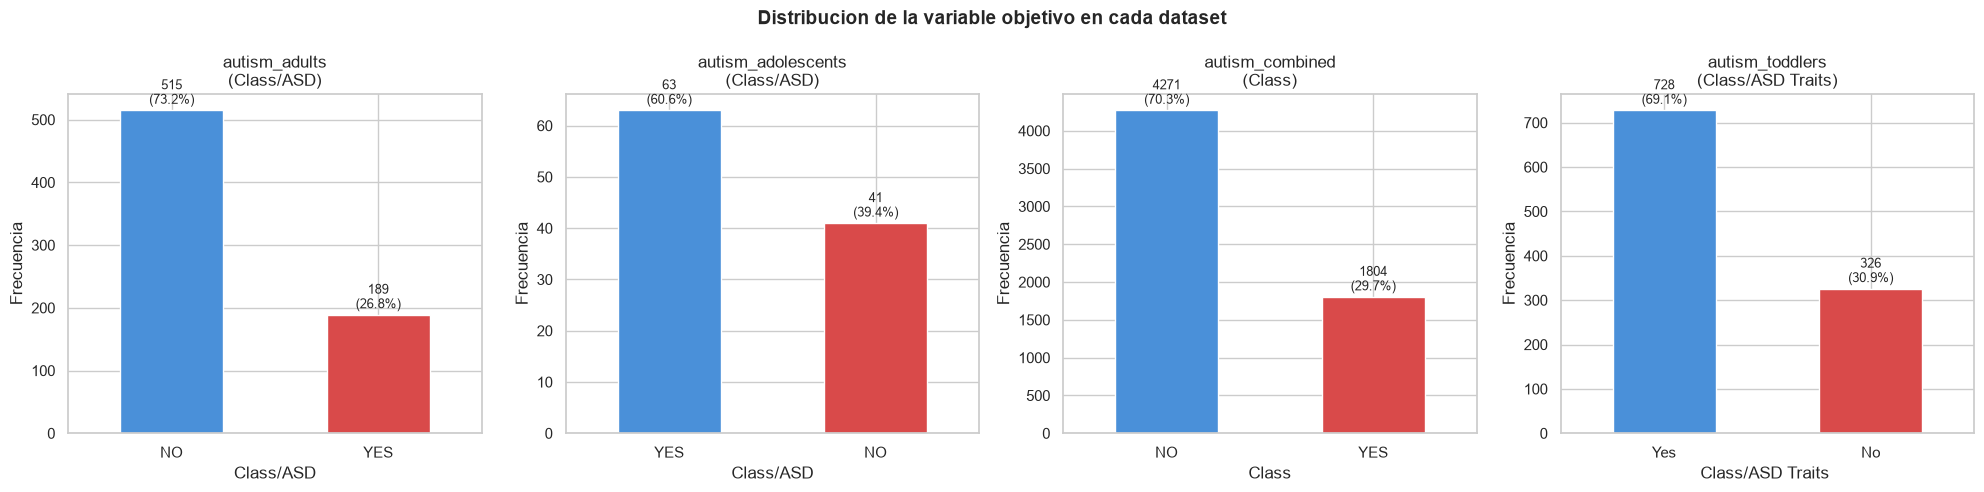

Resumen de balance de clases:
  autism_adults: NO=515 (73.2%) | YES=189 (26.8%)
  autism_adolescents: NO=41 (39.4%) | YES=63 (60.6%)
  autism_combined: NO=4271 (70.3%) | YES=1804 (29.7%)
  autism_toddlers: No=326 (30.9%) | Yes=728 (69.1%)


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

target_config = [
    (autism_adults, "Class/ASD", "autism_adults", axes[0]),
    (autism_adolescents, "Class/ASD", "autism_adolescents", axes[1]),
    (autism_combined, "Class", "autism_combined", axes[2]),
    (autism_toddlers, "Class/ASD Traits ", "autism_toddlers", axes[3]),
]

for data, target_col, nombre, ax in target_config:
    counts = data[target_col].value_counts()
    counts.plot(kind="bar", ax=ax, color=["#4a90d9", "#d94a4a"])
    ax.set_title(f"{nombre}\n({target_col.strip()})")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.02, f"{v}\n({v/len(data)*100:.1f}%)", ha="center", fontsize=9)

plt.suptitle("Distribucion de la variable objetivo en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen numerico
print("Resumen de balance de clases:")
for data, target_col, nombre, _ in target_config:
    counts = data[target_col].value_counts()
    no_key = [k for k in counts.index if k.strip().upper() == "NO"][0]
    yes_key = [k for k in counts.index if k.strip().upper() == "YES"][0]
    print(f"  {nombre}: {no_key}={counts[no_key]} ({counts[no_key]/len(data)*100:.1f}%) | {yes_key}={counts[yes_key]} ({counts[yes_key]/len(data)*100:.1f}%)")


### Observaciones sobre el balance de clases

- **autism_adults**: desbalanceado a favor de NO (73.2% NO vs 26.8% YES)
- **autism_adolescents**: tambien desbalanceado a favor de NO, dataset pequeno (104 registros)
- **autism_combined**: desbalanceado a favor de NO (70.3% NO vs 29.7% YES)
- **autism_toddlers**: desbalanceado a favor de YES (69.1% Yes vs 30.9% No) -- el caso inverso

El desbalance no es extremo en ninguno de los cuatro, pero es suficiente como
para que accuracy no sea una metrica fiable por si sola. Usaremos F1-score y
sobre todo recall como metricas principales.

El dataset de adolescentes es el mas pequeno con diferencia (104 registros),
lo que hay que tener en cuenta: cualquier modelo entrenado sobre el va a tener
mas varianza e incertidumbre que los otros. Esto es una limitacion que hay que
documentar en el analisis critico.


## 5. Distribucion de la edad

Analizamos como se distribuye la edad en cada dataset para entender la
poblacion que cubre cada uno.


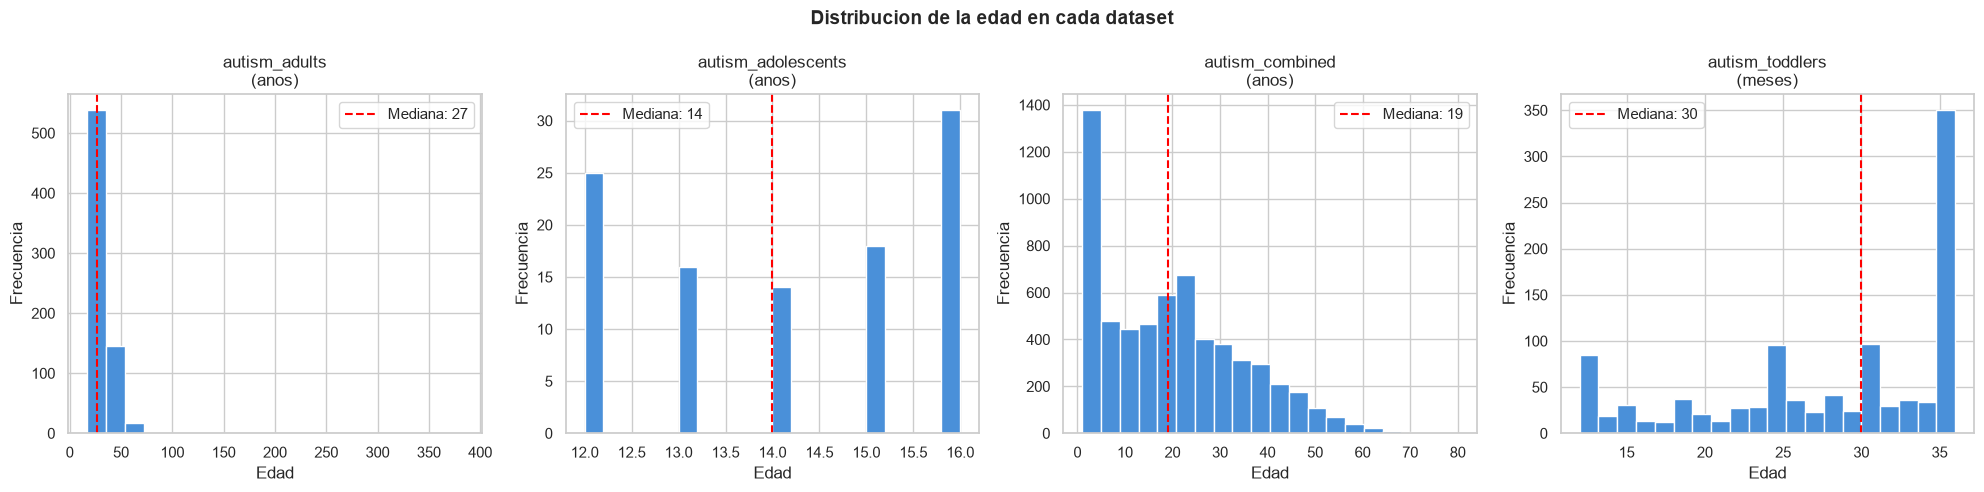

Estadisticos de edad:
  autism_adults: min=17.0, max=383.0, mediana=27, media=29.7
  autism_adolescents: min=12.0, max=16.0, mediana=14, media=14.1
  autism_combined: min=1, max=80, mediana=19, media=19.8
  autism_toddlers: min=12, max=36, mediana=30, media=27.9


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

age_config = [
    (autism_adults, "age", "autism_adults\n(anos)", axes[0]),
    (autism_adolescents, "age", "autism_adolescents\n(anos)", axes[1]),
    (autism_combined, "Age", "autism_combined\n(anos)", axes[2]),
    (autism_toddlers, "Age_Mons", "autism_toddlers\n(meses)", axes[3]),
]

for data, age_col, titulo, ax in age_config:
    data[age_col].hist(bins=20, ax=ax, color="#4a90d9", edgecolor="white")
    ax.set_title(titulo)
    ax.set_xlabel("Edad")
    ax.set_ylabel("Frecuencia")
    mediana = data[age_col].median()
    ax.axvline(mediana, color="red", linestyle="--", label=f"Mediana: {mediana:.0f}")
    ax.legend()

plt.suptitle("Distribucion de la edad en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/distribucion_edad.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadisticos descriptivos
print("Estadisticos de edad:")
for data, age_col, titulo, _ in age_config:
    print(f"  {titulo.split(chr(10))[0]}: min={data[age_col].min()}, max={data[age_col].max()}, mediana={data[age_col].median():.0f}, media={data[age_col].mean():.1f}")


### Observaciones sobre la edad

El dataset de adolescentes cubre el rango 12-16 anos aproximadamente, encajando
justo entre el dataset de ninos/toddlers y el de adultos. Esto confirma que
los cuatro datasets son complementarios en cuanto a cobertura de edad y que
tiene sentido entrenar un modelo especifico para cada franja.


## 6. Distribucion por sexo

El TEA tiene una prevalencia diferente segun el sexo: se diagnostica con mas
frecuencia en hombres que en mujeres, aunque hay evidencia de que en mujeres
puede estar infradiagnosticado porque la presentacion clinica es diferente.
Veamos como se distribuye el sexo en nuestros datasets.


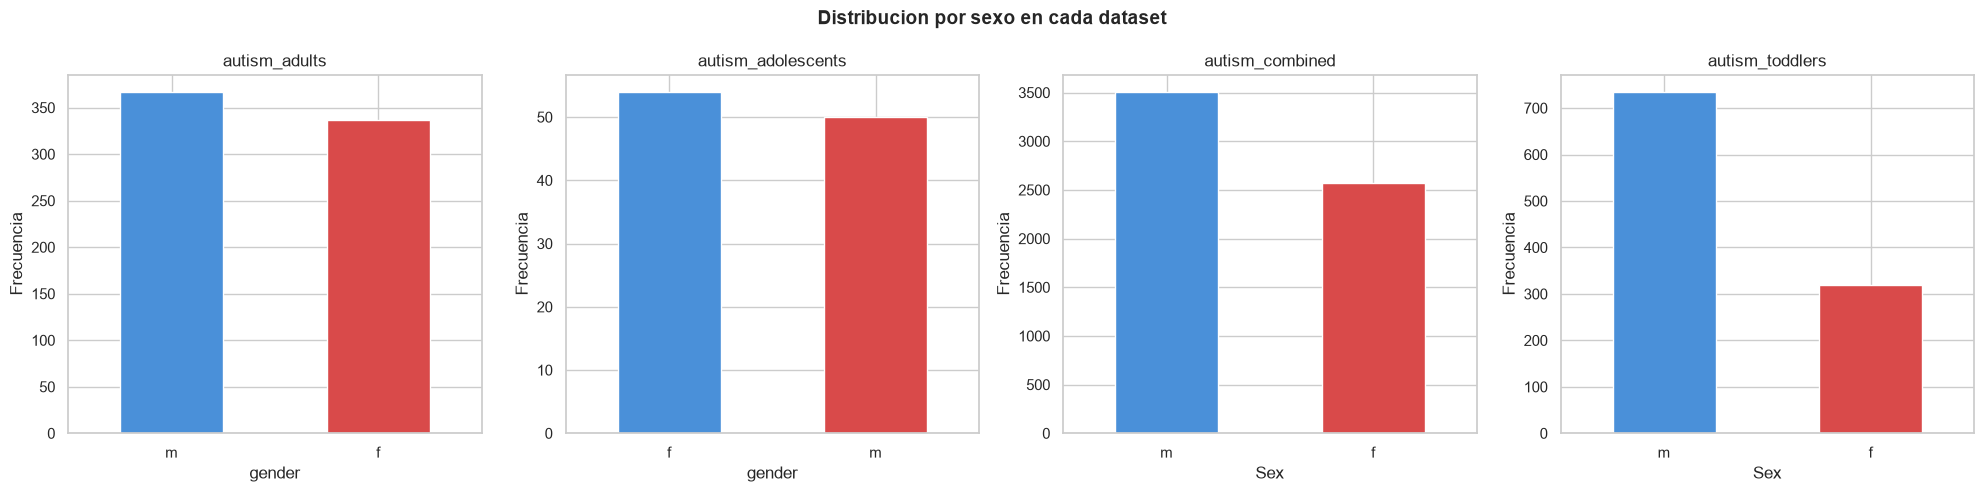

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sex_config = [
    (autism_adults, "gender", "autism_adults", axes[0]),
    (autism_adolescents, "gender", "autism_adolescents", axes[1]),
    (autism_combined, "Sex", "autism_combined", axes[2]),
    (autism_toddlers, "Sex", "autism_toddlers", axes[3]),
]

for data, sex_col, nombre, ax in sex_config:
    data[sex_col].value_counts().plot(kind="bar", ax=ax, color=["#4a90d9", "#d94a4a"])
    ax.set_title(nombre)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Distribucion por sexo en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/distribucion_sexo.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Antecedentes familiares de TEA

Los antecedentes familiares son un factor de riesgo conocido para el TEA.
Veamos como se distribuye esta variable y si tiene relacion con el resultado
del cribado en nuestros cuatro datasets.


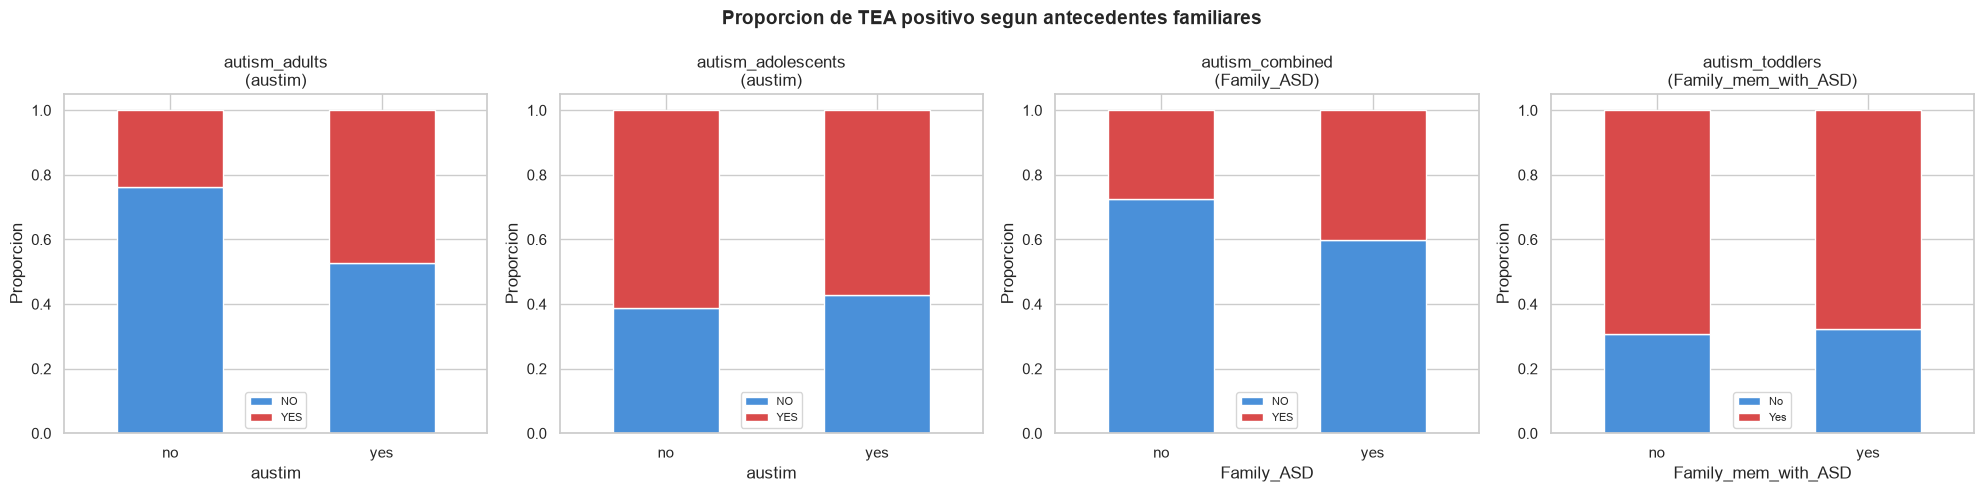

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

family_config = [
    (autism_adults, "austim", "Class/ASD", "autism_adults", axes[0]),
    (autism_adolescents, "austim", "Class/ASD", "autism_adolescents", axes[1]),
    (autism_combined, "Family_ASD", "Class", "autism_combined", axes[2]),
    (autism_toddlers, "Family_mem_with_ASD", "Class/ASD Traits ", "autism_toddlers", axes[3]),
]

for data, family_col, target_col, nombre, ax in family_config:
    pd.crosstab(data[family_col], data[target_col], normalize="index").plot(
        kind="bar", stacked=True, ax=ax, color=["#4a90d9", "#d94a4a"]
    )
    ax.set_title(f"{nombre}\n({family_col})")
    ax.set_ylabel("Proporcion")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8)

plt.suptitle("Proporcion de TEA positivo segun antecedentes familiares", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/antecedentes_familiares.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Ictericia neonatal (jaundice)

La ictericia neonatal se ha estudiado como posible factor de riesgo asociado
al TEA. Veamos como se distribuye en nuestros datasets y si hay diferencia
en el resultado del cribado.


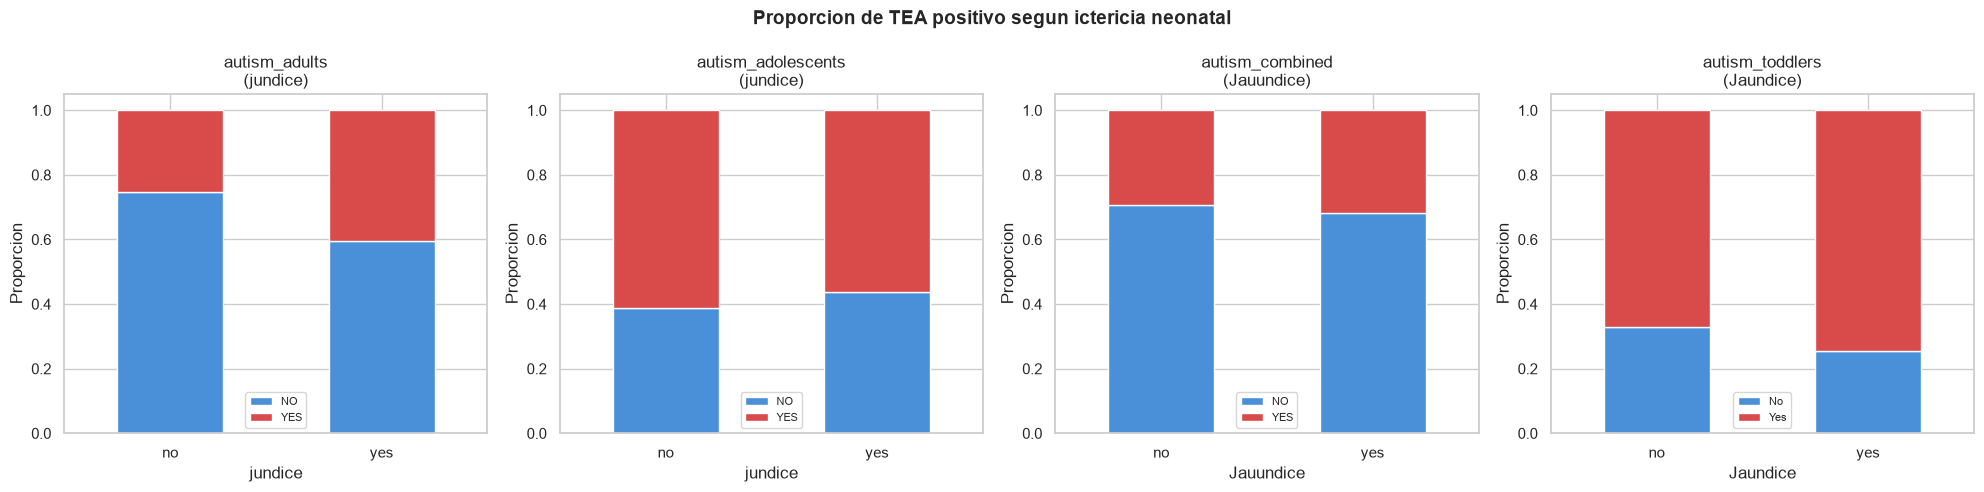

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

jaundice_config = [
    (autism_adults, "jundice", "Class/ASD", "autism_adults", axes[0]),
    (autism_adolescents, "jundice", "Class/ASD", "autism_adolescents", axes[1]),
    (autism_combined, "Jauundice", "Class", "autism_combined", axes[2]),
    (autism_toddlers, "Jaundice", "Class/ASD Traits ", "autism_toddlers", axes[3]),
]

for data, jaundice_col, target_col, nombre, ax in jaundice_config:
    pd.crosstab(data[jaundice_col], data[target_col], normalize="index").plot(
        kind="bar", stacked=True, ax=ax, color=["#4a90d9", "#d94a4a"]
    )
    ax.set_title(f"{nombre}\n({jaundice_col})")
    ax.set_ylabel("Proporcion")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8)

plt.suptitle("Proporcion de TEA positivo segun ictericia neonatal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/ictericia_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Distribucion de las respuestas del cuestionario AQ-10

Las columnas A1 a A10 contienen las respuestas a las 10 preguntas del
cuestionario AQ-10. Cada respuesta es binaria (0 o 1). Vamos a ver
como se distribuyen las respuestas y si alguna pregunta tiene mas
poder predictivo que las demas, comparando los cuatro datasets.


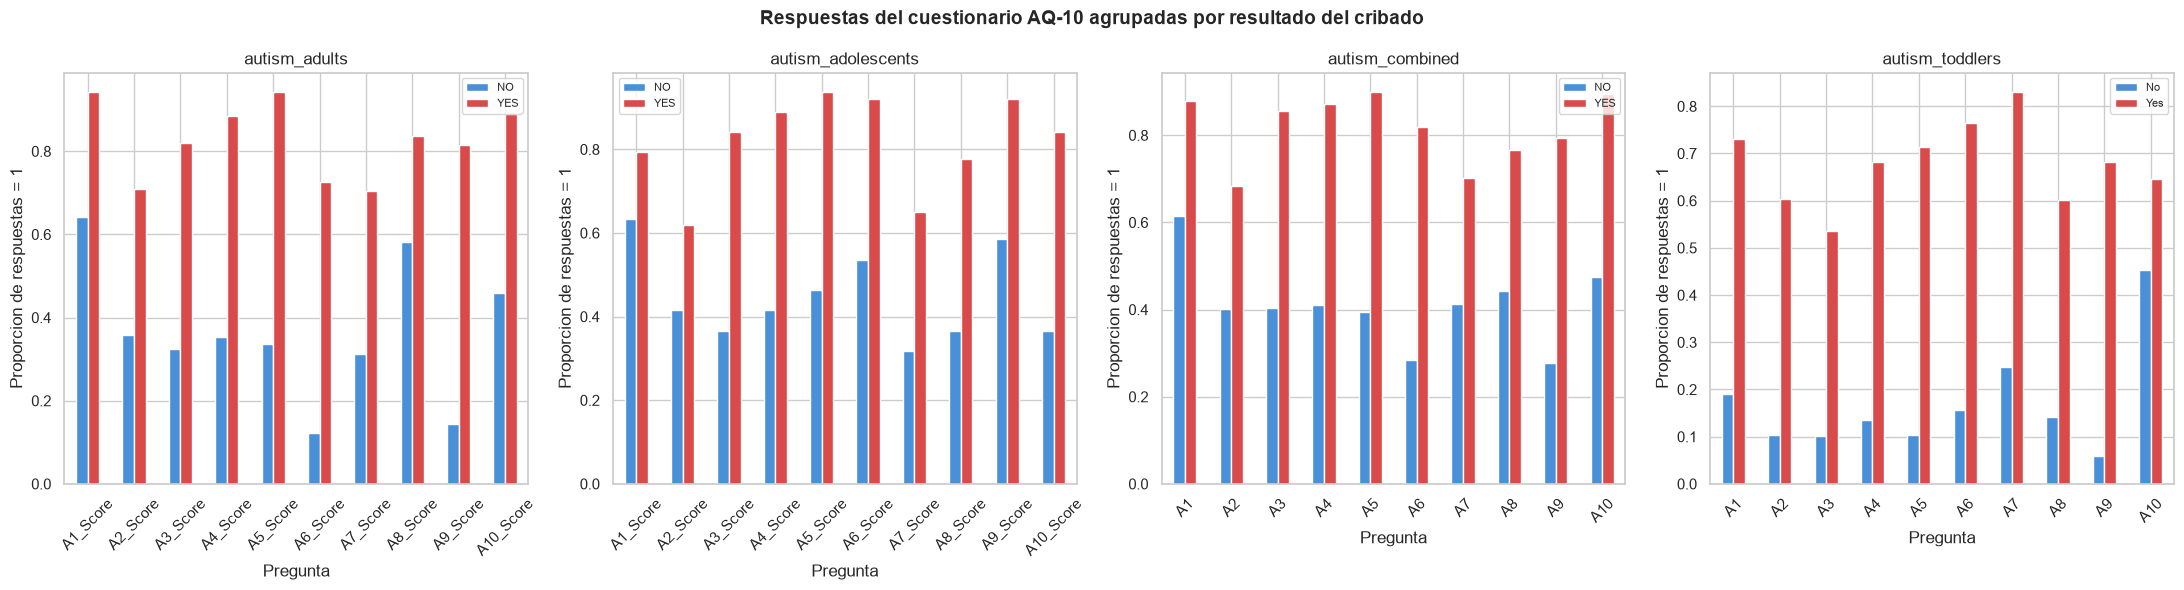

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

score_cols_adults = [f"A{i}_Score" for i in range(1, 11)]
score_cols_combined = [f"A{i}" for i in range(1, 11)]
score_cols_toddlers = [f"A{i}" for i in range(1, 11)]

aq_config = [
    (autism_adults, score_cols_adults, "Class/ASD", "autism_adults", axes[0]),
    (autism_adolescents, score_cols_adults, "Class/ASD", "autism_adolescents", axes[1]),
    (autism_combined, score_cols_combined, "Class", "autism_combined", axes[2]),
    (autism_toddlers, score_cols_toddlers, "Class/ASD Traits ", "autism_toddlers", axes[3]),
]

for data, score_cols, target_col, nombre, ax in aq_config:
    medias = data.groupby(target_col)[score_cols].mean()
    medias.T.plot(kind="bar", ax=ax, color=["#4a90d9", "#d94a4a"])
    ax.set_title(f"{nombre}")
    ax.set_ylabel("Proporcion de respuestas = 1")
    ax.set_xlabel("Pregunta")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.suptitle("Respuestas del cuestionario AQ-10 agrupadas por resultado del cribado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/respuestas_aq10.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones sobre las respuestas AQ-10

Este grafico es clave para el proyecto. Muestra que hay preguntas donde la
diferencia entre los que dan positivo y negativo en el cribado es muy grande.
Esas preguntas seran probablemente las features mas importantes para el modelo.

El patron de preguntas discriminativas es similar entre adultos y adolescentes,
lo cual tiene sentido porque comparten el mismo cuestionario AQ-10 (a diferencia
de toddlers, que usa el Q-CHAT-10, una version adaptada a la primera infancia).


## 10. Matriz de correlacion

Calculamos la correlacion entre las variables numericas de cada dataset.
Esto nos ayuda a detectar si hay variables redundantes (muy correlacionadas
entre si) que podriamos eliminar o combinar.


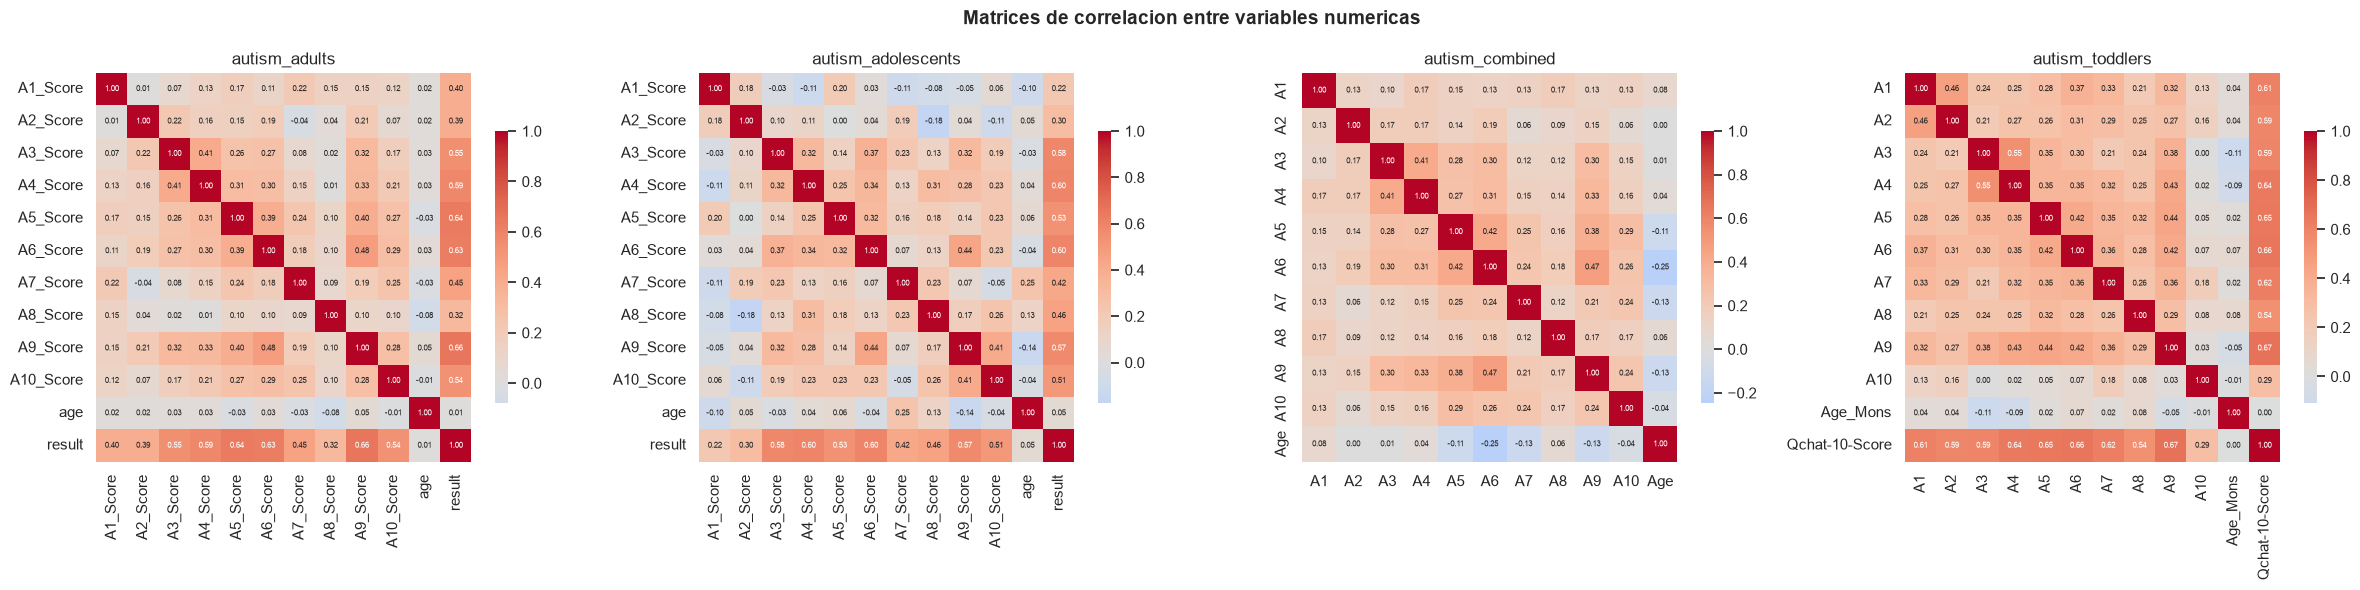

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

corr_adults = autism_adults[score_cols_adults + ["age", "result"]].corr()
sns.heatmap(corr_adults, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], cbar_kws={"shrink": 0.7}, annot_kws={"size": 6})
axes[0].set_title("autism_adults")

corr_adolescents = autism_adolescents[score_cols_adults + ["age", "result"]].corr()
sns.heatmap(corr_adolescents, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], cbar_kws={"shrink": 0.7}, annot_kws={"size": 6})
axes[1].set_title("autism_adolescents")

corr_combined = autism_combined[score_cols_combined + ["Age"]].corr()
sns.heatmap(corr_combined, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[2], cbar_kws={"shrink": 0.7}, annot_kws={"size": 6})
axes[2].set_title("autism_combined")

corr_toddlers = autism_toddlers[score_cols_toddlers + ["Age_Mons", "Qchat-10-Score"]].corr()
sns.heatmap(corr_toddlers, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[3], cbar_kws={"shrink": 0.7}, annot_kws={"size": 6})
axes[3].set_title("autism_toddlers")

plt.suptitle("Matrices de correlacion entre variables numericas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/correlacion.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones sobre la correlacion

- Las respuestas del cuestionario (A1 a A10) tienen correlaciones bajas-moderadas
  entre si en general en los cuatro datasets, lo cual es bueno: cada pregunta
  aporta informacion diferente y no son redundantes.
- La edad no esta fuertemente correlacionada con ninguna respuesta del cuestionario
  en ningun dataset.
- 'result' (adults, adolescents) y 'Qchat-10-Score' (toddlers) son la suma de las
  respuestas individuales, asi que estan logicamente muy correlacionadas con ellas.
  No las usaremos como features en el modelado para evitar data leakage.


## 11. Puntuacion total del cuestionario vs resultado del cribado

Visualizamos la distribucion de la puntuacion total del cuestionario
(suma de A1 a A10) separada por resultado del cribado, en los cuatro datasets.


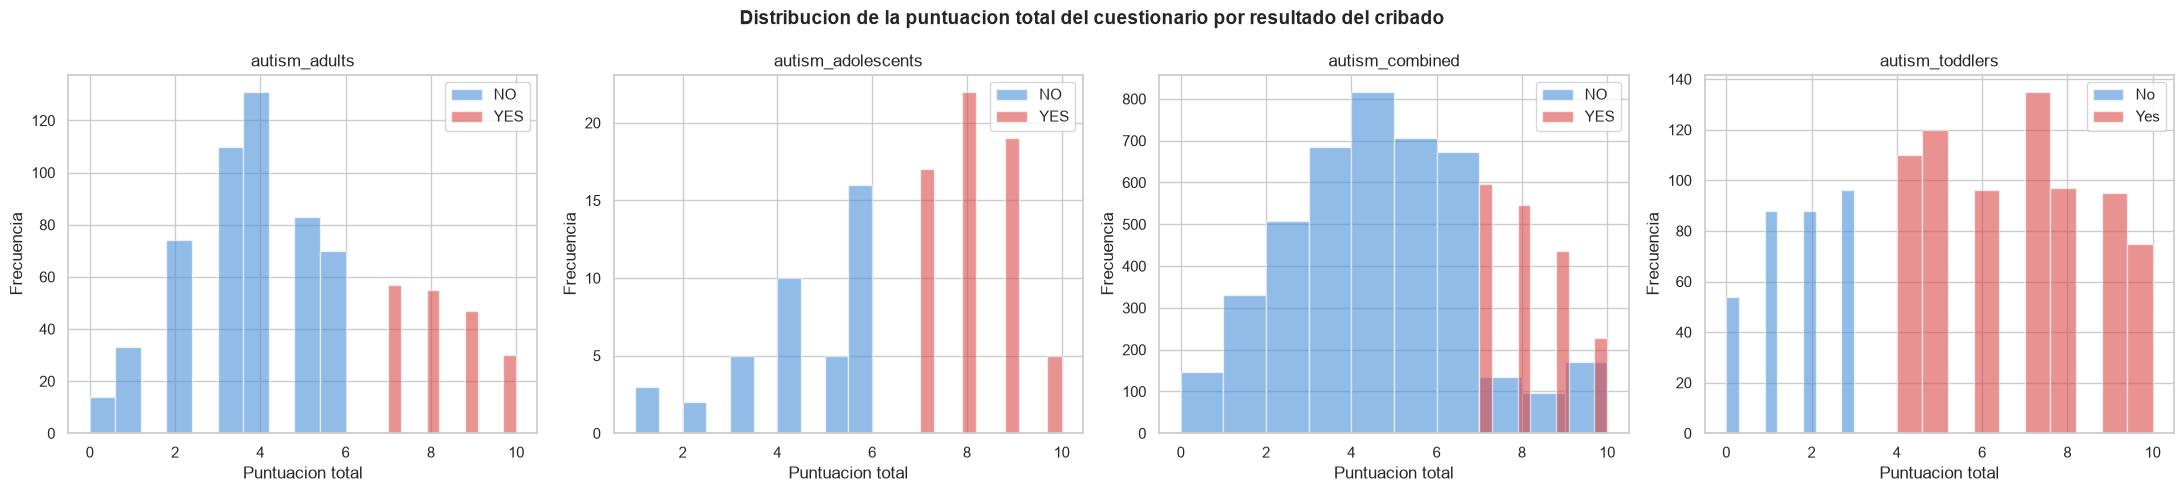

In [24]:
autism_adults["score_total"] = autism_adults[score_cols_adults].sum(axis=1)
autism_adolescents["score_total"] = autism_adolescents[score_cols_adults].sum(axis=1)
autism_combined["score_total"] = autism_combined[score_cols_combined].sum(axis=1)
autism_toddlers["score_total"] = autism_toddlers[score_cols_toddlers].sum(axis=1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

score_target_config = [
    (autism_adults, "Class/ASD", ["NO", "YES"], "autism_adults", axes[0]),
    (autism_adolescents, "Class/ASD", ["NO", "YES"], "autism_adolescents", axes[1]),
    (autism_combined, "Class", ["NO", "YES"], "autism_combined", axes[2]),
    (autism_toddlers, "Class/ASD Traits ", ["No", "Yes"], "autism_toddlers", axes[3]),
]

for data, target_col, clases, nombre, ax in score_target_config:
    for clase in clases:
        subset = data[data[target_col] == clase]
        ax.hist(subset["score_total"], bins=10, alpha=0.6, label=clase,
                color="#4a90d9" if clase.upper() == "NO" else "#d94a4a", edgecolor="white")
    ax.set_title(nombre)
    ax.set_xlabel("Puntuacion total")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.suptitle("Distribucion de la puntuacion total del cuestionario por resultado del cribado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/score_total_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones sobre la puntuacion total

Las distribuciones de puntuacion total estan bastante separadas entre las dos
clases en los cuatro datasets, incluido el de adolescentes a pesar de su tamano
mas reducido. Esto confirma que las respuestas del cuestionario contienen
informacion predictiva real en todas las franjas de edad.


## 12. Resumen del EDA y decisiones para el preprocesamiento

### Hallazgos principales

1. **Tamano de los datasets**: autism_adults (704), autism_adolescents (104),
   autism_combined (6075), autism_toddlers (1054). En total, 7937 registros
   entre los cuatro.

2. **Formato de origen distinto**: adolescentes viene en ARFF, no CSV. Requiere
   decodificar bytes a string y convertir las columnas A1_Score-A10_Score de
   texto a entero antes de poder operar con ellas.

3. **Valores faltantes**: 2 en la columna 'age' de autism_adults. Tambien hay
   valores '?' en columnas categoricas de autism_adults y autism_adolescents
   que deben tratarse como categoria "desconocido" o imputarse con la moda.

4. **Desbalance de clases**: presente en los cuatro datasets, mas pronunciado
   en toddlers (a favor de Yes) y moderado en el resto (a favor de No). No es
   extremo en ningun caso.
   Decision: usar pesos de clase ajustados (class_weight='balanced') y
   priorizar recall como metrica principal.

5. **Tamano reducido de adolescentes**: con solo 104 registros, el modelo para
   este grupo de edad va a tener mas incertidumbre y varianza que los demas.
   Esto se debe documentar explicitamente como limitacion en el analisis critico.

6. **Senal predictiva**: las respuestas del cuestionario AQ-10 separan bien las
   dos clases en los cuatro datasets, incluido adolescentes.

7. **Columnas a excluir del feature set** (en los 4 datasets):
   - 'result' (adults, adolescents) y 'Qchat-10-Score' (toddlers): son la suma
     de A1-A10, usarlas seria casi como usar el target como feature.
   - 'score_total': la hemos calculado nosotros, mismo problema.
   - 'age_desc': redundante con 'age'.
   - 'Case_No' (toddlers): es un identificador, no aporta informacion.

8. **Sesgo potencial**: el dataset esta dominado por poblacion anglosajona y los
   criterios de cribado son DSM-5. La presentacion clinica del TEA en mujeres
   puede diferir, lo que podria afectar al rendimiento del modelo en poblaciones
   subrepresentadas. Esto es una limitacion que documentaremos explicitamente.

### Decisiones para el preprocesamiento (notebook 02)

- Entrenar un modelo por grupo de edad (adults, adolescents, combined, toddlers),
  ya que cada uno tiene su propio cuestionario adaptado y columnas demograficas
  distintas.
- Decodificar bytes y convertir tipos del dataset de adolescentes ANTES de
  cualquier otro procesamiento.
- Imputar los 2 valores faltantes de 'age' con la mediana.
- Tratar los '?' como categoria 'unknown' o imputar con la moda.
- Aplicar One-Hot Encoding a las variables categoricas.
- Escalar las variables numericas (edad) con StandardScaler.
- Dividir en 80% train / 20% test ANTES de ajustar cualquier transformacion.
- Usar Pipeline de scikit-learn para evitar data leakage.
- Documentar el tamano reducido de autism_adolescents como limitacion del proyecto.
